In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import defaultdict
import glob
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
from nltk.stem import WordNetLemmatizer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

# stop_words = set(stopwords.words('english'))

custom_stopwords = {
    'dont','didnt','doesnt','would','could','one','get','got',
    'really','also','even','much','many','well','make','made','still',
    'thing','things','something','anything','everything','way','lot',
    'first','second','third','time','day','week','month','year',
    'ive','im','youre','theyre','cant','wont','couldnt','wouldnt',
    'product','item','order','ordered','buy','bought', 'isnt',
    'purchase','purchased','using','use','used', 'looking','look',
    'said', 'shoe', 'box', 'came', 'work', 'put', 'door'
}

stop_words = set(stopwords.words('english')).union(custom_stopwords)


base_path = Path("/content/drive/MyDrive/Jewelry_Project/Jewelry_review_files/")
year_folders = sorted(base_path.glob("year=*"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"n't", " not", text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return tokens
def get_word_freq(token_series):
    all_words = []
    for tokens in token_series:
        all_words.extend(tokens)
    return Counter(all_words)

all_products=[]
reviews_per_brand = defaultdict(int)
for year_folder in year_folders:
    year = int(year_folder.name.split("=")[1])
    for file in year_folder.glob("*.parquet"):
        df = pd.read_parquet(file, columns=["parent_asin", "asin", "brand", "rating", 'price', "review"]) #rating here is reviewer's rating
        df = df.dropna(subset=["parent_asin", "asin", "brand", "rating", 'price',"review"])
        df["review"]=df["review"].astype(str).str.strip()
        df["brand"]=df["brand"].astype(str).str.strip()
        not_brand = {"", "unknown", "generic", "unbranded", "none", "nan", "/n"}
        df = df[~df["brand"].str.lower().isin(not_brand)]
        df["price"] = pd.to_numeric(df["price"], errors="coerce")
        df = df[df["price"] > 0]
        df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
        df = df[(df["rating"] > 0) & (df["rating"] <= 5)]
        df['year']=year
        all_products.append(df)
products=pd.concat(all_products, ignore_index=True)
products["price_segment"] = np.select([products["price"] < 100,(products["price"] >= 100) & (products["price"] <= 1000),products["price"] > 1000],["cheap", "mid", "luxury"],default="unknown")
# products.head(10)
# print(products[products["price_segment"] == "luxury"].head(5))
products["sentiment"] = np.select([products["rating"] <=2.5 ,(products["rating"] >= 2.5) & (products["rating"] <= 3.5),products["rating"] > 3.5],["negative", "neutral", "positive"],default="unknown")

tqdm.pandas()
products['tokens'] = products['review'].progress_apply(clean_text)
results = {}
for segment in ['cheap', 'mid', 'luxury']:
    for sentiment in ['positive', 'neutral', 'negative']:
        subset = products[(products['price_segment'] == segment) & (products['sentiment'] == sentiment)]
        word_freq = get_word_freq(subset['tokens'])
        results[(segment, sentiment)] = word_freq

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
100%|██████████| 1144381/1144381 [04:00<00:00, 4760.49it/s]


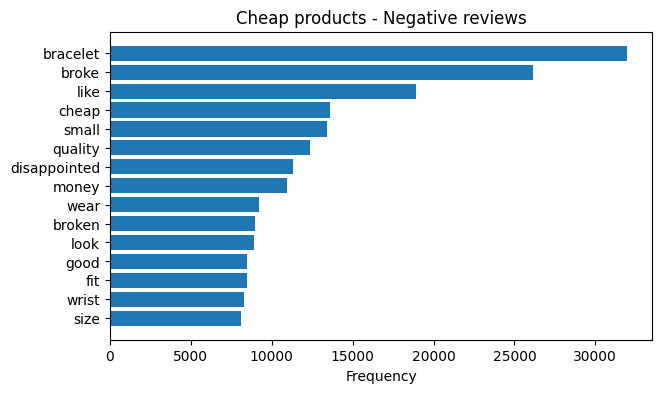

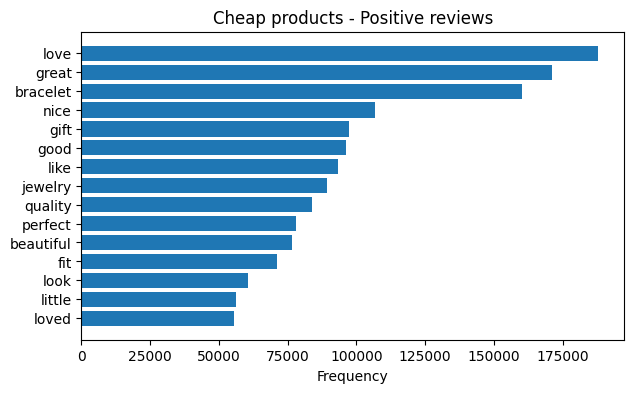

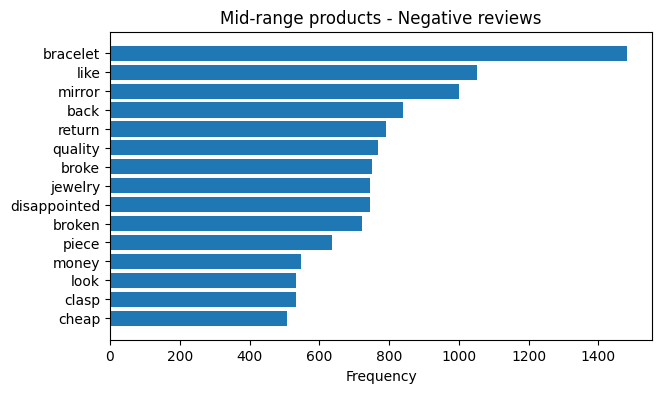

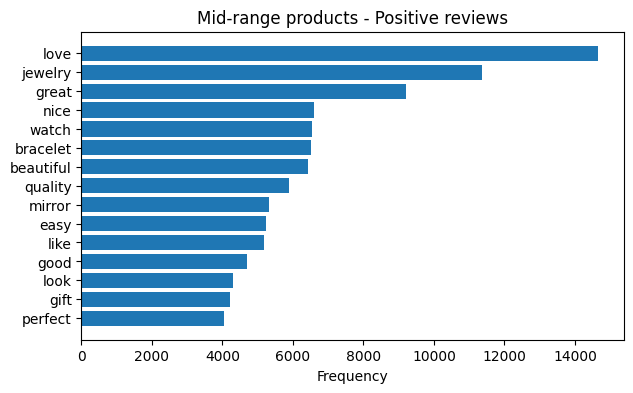

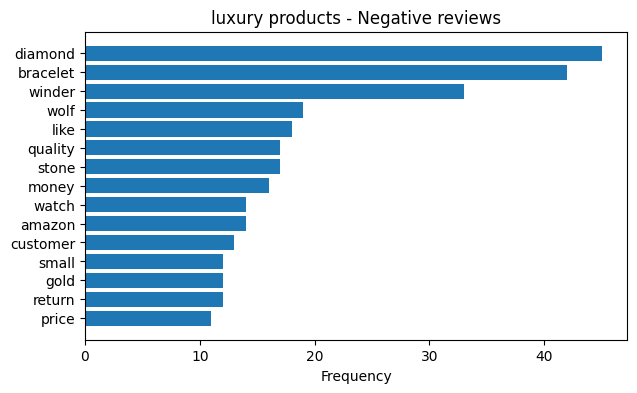

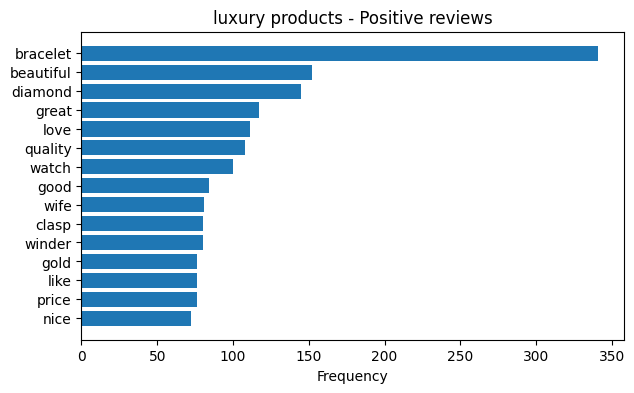

In [4]:
def plot_top_words(word_freq, title, top_n=15):
    common = word_freq.most_common(top_n)
    words = [w[0] for w in common]
    counts = [w[1] for w in common]
    plt.figure(figsize=(7, 4))
    plt.barh(words[::-1], counts[::-1])
    plt.title(title)
    plt.xlabel("Frequency")
    plt.show()

plot_top_words(results[('cheap', 'negative')], "Cheap products - Negative reviews")
plot_top_words(results[('cheap', 'positive')], "Cheap products - Positive reviews")
plot_top_words(results[('mid', 'negative')], "Mid-range products - Negative reviews")
plot_top_words(results[('mid', 'positive')], "Mid-range products - Positive reviews")
plot_top_words(results[('luxury', 'negative')], "luxury products - Negative reviews")
plot_top_words(results[('luxury', 'positive')], "luxury products - Positive reviews")

word cloud


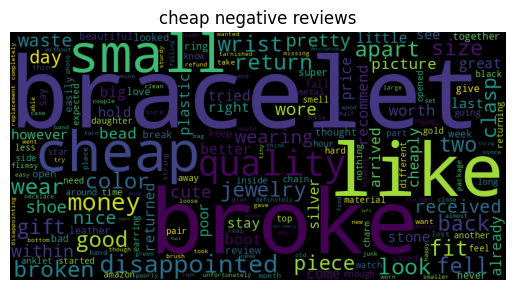

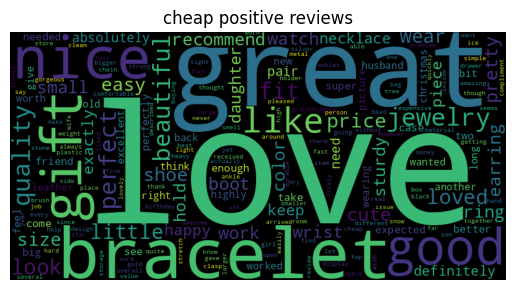

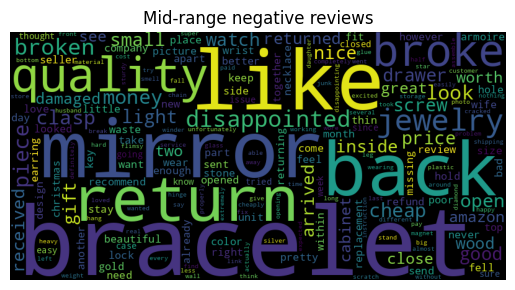

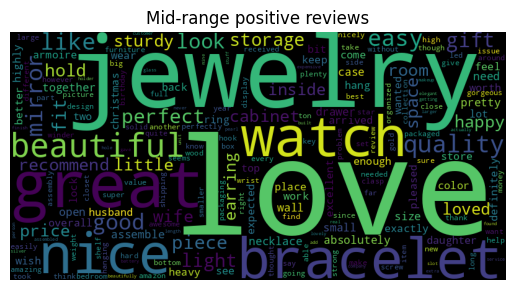

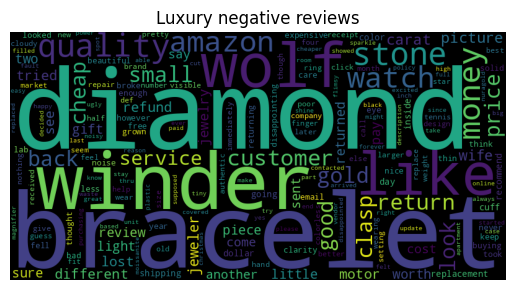

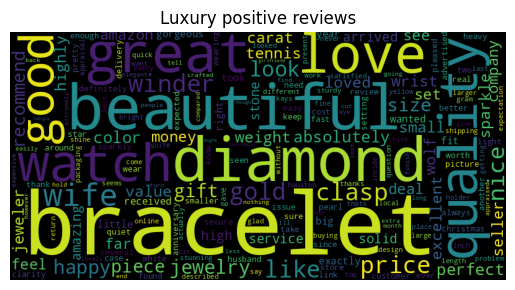

In [5]:
print("word cloud")
def plot_wordcloud(word_freq, title):
    wc = WordCloud(width=800, height=400).generate_from_frequencies(word_freq)
    plt.figure()
    plt.imshow(wc)
    plt.axis("off")
    plt.title(title)
    plt.show()
plot_wordcloud(results[('cheap', 'negative')], "cheap negative reviews")
plot_wordcloud(results[('cheap', 'positive')], "cheap positive reviews")
plot_wordcloud(results[('mid', 'negative')], "Mid-range negative reviews")
plot_wordcloud(results[('mid', 'positive')], "Mid-range positive reviews")
plot_wordcloud(results[('luxury', 'negative')], "Luxury negative reviews")
plot_wordcloud(results[('luxury', 'positive')], "Luxury positive reviews")

word trends over years for each brand


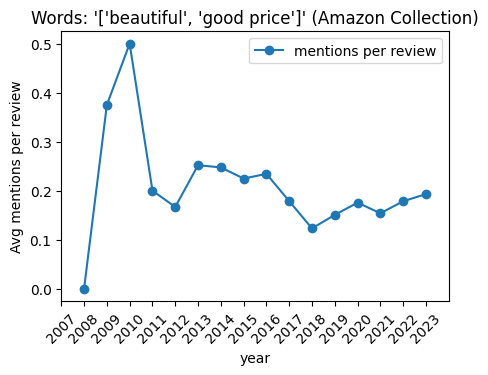

In [10]:
print("word trends over years for each brand")
def word_trend(df, words, brand=None):
    data = df.copy()
    if brand:
        data = data[data['brand'].str.strip().str.lower() == brand.strip().lower()]
    words = [w.lower() for w in words]
    pattern = r'\b(' + '|'.join(map(re.escape, words)) + r')\b'
    data['word_count'] = data['review'].str.count(pattern, flags=re.IGNORECASE)
    # data['contains_word'] = data['tokens'].apply(lambda x: any(w in x for w in words))
    # data['word_count'] = data['tokens'].apply(lambda tokens: sum(tokens.count(w) for w in words))
    trend = data.groupby('year')['word_count'].sum()
    price = data.groupby('year')['price'].median()
    total_reviews = data.groupby('year')['review'].count()
    plt.figure(figsize=(5, 3.5))
    norm_trend=trend/total_reviews
    norm_trend.plot(marker='o', label='mentions per review')
    # price.plot(marker='*', label='price')
    plt.title(f"Words: '{words}'" + (f" ({brand})" if brand else ""))
    plt.ylabel("Avg mentions per review")
    plt.xlim(2007, 2024)
    plt.xticks(np.arange(2007, 2024, 1), rotation=45)
    plt.legend()
    plt.show()
word_trend(products, ['beautiful', 'good price'], brand='Amazon Collection') #Lenox

compare words in price segments
quality problem


/tmp/ipykernel_9803/3421405955.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)


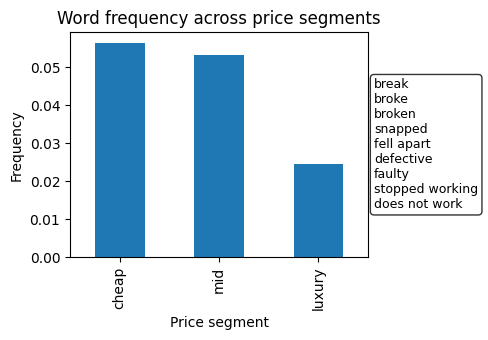

               total_reviews  reviews_with_word     share
price_segment                                            
cheap                1090549              61552  0.056441
mid                    53182               2840  0.053402
luxury                   650                 16  0.024615


/tmp/ipykernel_9803/3421405955.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)


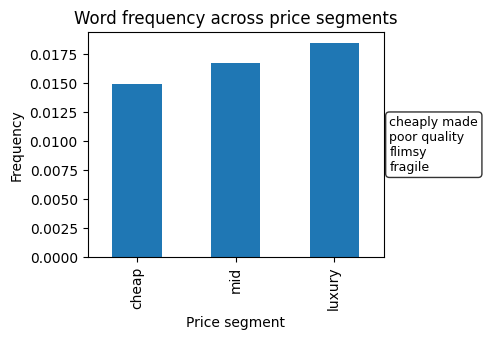

               total_reviews  reviews_with_word     share
price_segment                                            
cheap                1090549              16300  0.014947
mid                    53182                888  0.016697
luxury                   650                 12  0.018462
size problem


/tmp/ipykernel_9803/3421405955.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)


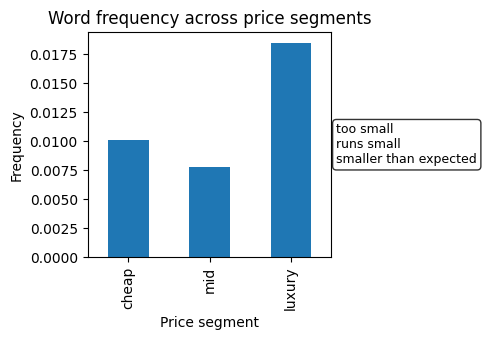

               total_reviews  reviews_with_word     share
price_segment                                            
cheap                1090549              11056  0.010138
mid                    53182                415  0.007803
luxury                   650                 12  0.018462


/tmp/ipykernel_9803/3421405955.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)


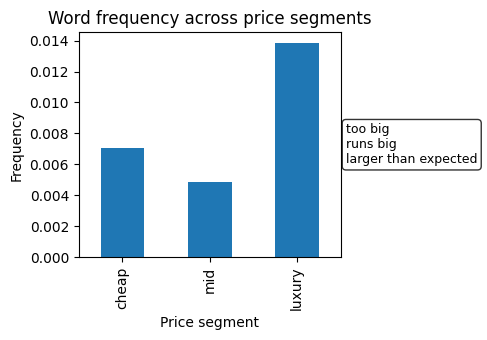

               total_reviews  reviews_with_word     share
price_segment                                            
cheap                1090549               7661  0.007025
mid                    53182                260  0.004889
luxury                   650                  9  0.013846


/tmp/ipykernel_9803/3421405955.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)


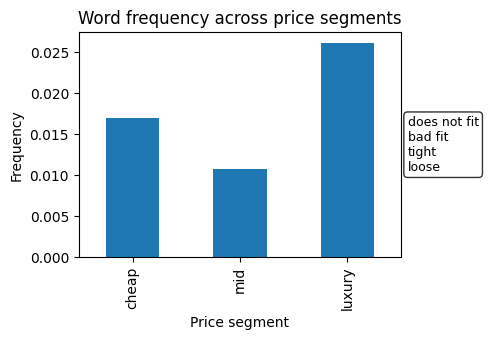

               total_reviews  reviews_with_word     share
price_segment                                            
cheap                1090549              18526  0.016988
mid                    53182                572  0.010756
luxury                   650                 17  0.026154
appearance mismatch


/tmp/ipykernel_9803/3421405955.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)


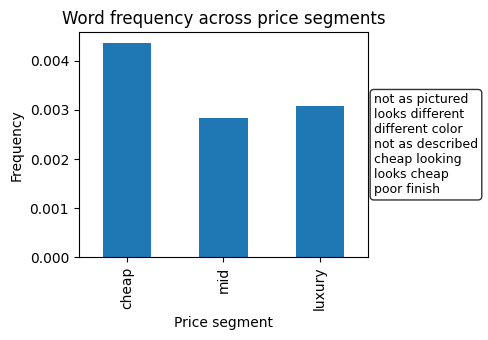

               total_reviews  reviews_with_word     share
price_segment                                            
cheap                1090549               4761  0.004366
mid                    53182                151  0.002839
luxury                   650                  2  0.003077
comfort/usability


/tmp/ipykernel_9803/3421405955.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)


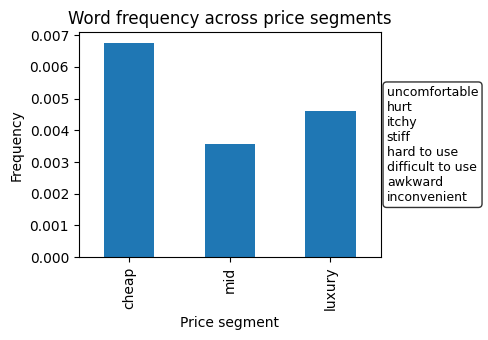

               total_reviews  reviews_with_word     share
price_segment                                            
cheap                1090549               7365  0.006753
mid                    53182                189  0.003554
luxury                   650                  3  0.004615
price


/tmp/ipykernel_9803/3421405955.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)


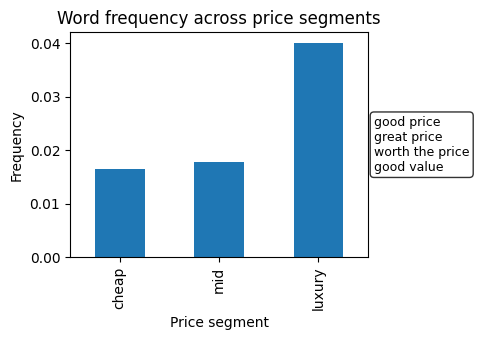

               total_reviews  reviews_with_word     share
price_segment                                            
cheap                1090549              17895  0.016409
mid                    53182                944  0.017750
luxury                   650                 26  0.040000


/tmp/ipykernel_9803/3421405955.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)


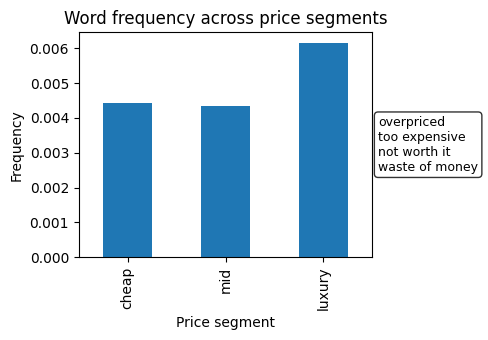

               total_reviews  reviews_with_word     share
price_segment                                            
cheap                1090549               4817  0.004417
mid                    53182                231  0.004344
luxury                   650                  4  0.006154


/tmp/ipykernel_9803/3421405955.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)


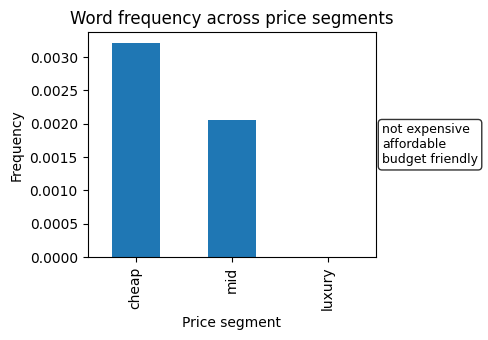

               total_reviews  reviews_with_word     share
price_segment                                            
cheap                1090549               3500  0.003209
mid                    53182                109  0.002050
luxury                   650                  0  0.000000
positive comments


/tmp/ipykernel_9803/3421405955.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)


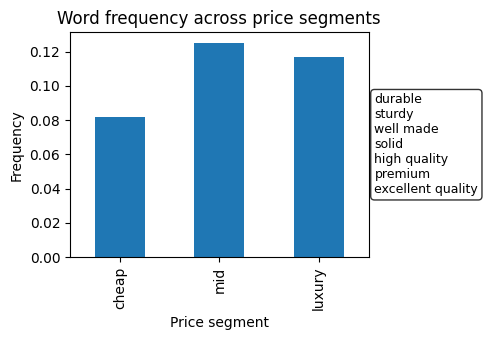

               total_reviews  reviews_with_word     share
price_segment                                            
cheap                1090549              89097  0.081699
mid                    53182               6648  0.125005
luxury                   650                 76  0.116923


/tmp/ipykernel_9803/3421405955.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)


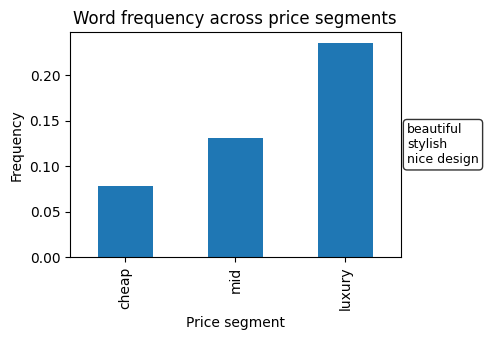

               total_reviews  reviews_with_word     share
price_segment                                            
cheap                1090549              85375  0.078286
mid                    53182               6945  0.130589
luxury                   650                153  0.235385


In [17]:
print("compare words in price segments")
def compare_word_across_segments(df, words):
    words = [w.lower() for w in words]
    pattern = r'\b(' + '|'.join(map(re.escape, words)) + r')\b'
    df = df.copy()
    df['contains_word'] = df['review'].str.contains(pattern, case=False, na=False)
    # df['contains_word'] = df['tokens'].apply(lambda x: any(w in x for w in words))
    result = df.groupby('price_segment').agg(total_reviews=('contains_word', 'size'),reviews_with_word=('contains_word', 'sum'))
    result['share'] = result['reviews_with_word'] / result['total_reviews']
    result = result.reindex(['cheap', 'mid', 'luxury'])
    plt.figure(figsize=(5, 3.5))
    result['share'].plot(kind='bar')
    # Create text box with words (each on new line)
    word_text = "\n".join(words)
    plt.gca().text(1.02, 0.5, word_text,transform=plt.gca().transAxes, fontsize=9,verticalalignment='center',
                   bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    plt.title("Word frequency across price segments")
    plt.xlabel("Price segment")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
    print(result)
print("quality problem")
compare_word_across_segments(products, ['break', 'broke', 'broken', 'snapped', 'fell apart', 'defective', 'faulty', 'stopped working', 'does not work'])
compare_word_across_segments(products, ['cheaply made', 'poor quality', 'flimsy', 'fragile'])
print("size problem")
compare_word_across_segments(products, ['too small', 'runs small', 'smaller than expected'])
compare_word_across_segments(products, ['too big', 'runs big', 'larger than expected'])
compare_word_across_segments(products, ['does not fit', 'bad fit', 'tight', 'loose'])
print("appearance mismatch")
compare_word_across_segments(products, ['not as pictured', 'looks different', 'different color', 'not as described','cheap looking', 'looks cheap', 'poor finish'])
print("comfort/usability")
compare_word_across_segments(products, ['uncomfortable', 'hurt', 'itchy', 'stiff','hard to use', 'difficult to use', 'awkward', 'inconvenient'])
print("price")
compare_word_across_segments(products, ['good price', 'great price', 'worth the price', 'good value'])
compare_word_across_segments(products, ['overpriced', 'too expensive', 'not worth it', 'waste of money'])
compare_word_across_segments(products, ['not expensive', 'affordable', 'budget friendly'])
print("positive comments")
compare_word_across_segments(products, ['durable', 'sturdy', 'well made', 'solid', 'high quality', 'premium', 'excellent quality'])
compare_word_across_segments(products, ['beautiful', 'stylish', 'nice design'])


buisiness insights
             word  reviews_mentioning_word     share
37      ballerina                       57  0.351852
22          music                       50  0.308642
24        jewelry                       40  0.246914
5        daughter                       38  0.234568
150  disappointed                       33  0.203704
86           gift                       30  0.185185
58         broken                       30  0.185185
212        opened                       28  0.172840
75        quality                       28  0.172840
59          lenox                       28  0.172840
[('ballerina spin', 9), ('play music', 8), ('little girl', 8), ('arrived broken', 7), ('music play', 7), ('lid close', 7), ('christmas gift', 7), ('music ballerina', 6), ('poor quality', 6), ('ballerina mechanism', 5)]


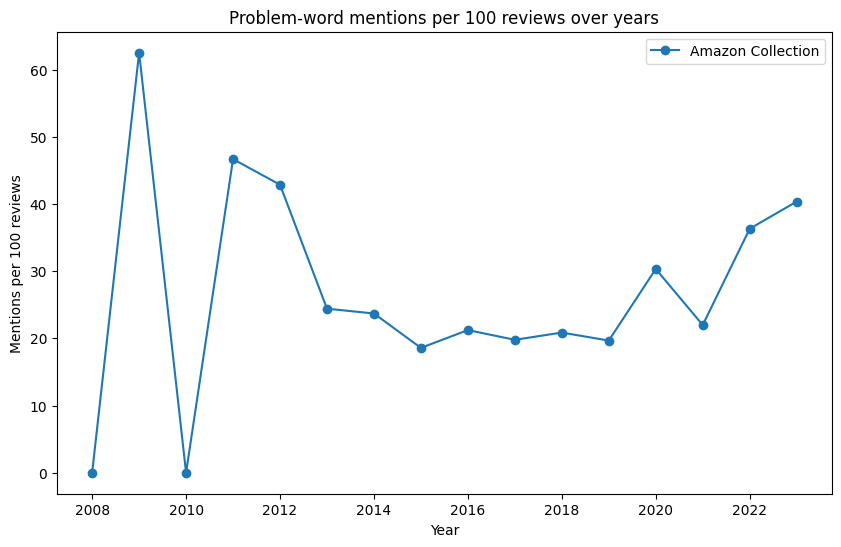

        brand  year  problem_word  reviews_mentioning_word  share_of_reviews
0          01  2020         cheap                        1          0.100000
1          01  2021         small                        1          0.076923
2     123Arts  2018        broken                        1          0.200000
3     123Arts  2019        damage                        2          0.125000
4     123Arts  2019         cheap                        1          0.062500
5     123Arts  2019         small                        1          0.062500
6     123Arts  2020         small                        1          0.062500
7     123Arts  2022         small                        1          0.142857
8     123Arts  2023        defect                        1          0.333333
9     123Arts  2023           bad                        1          0.333333
10  168 GIFTS  2021          poor                        2          0.500000
11  168 GIFTS  2021  poor quality                        1          0.250000

In [18]:
print("buisiness insights")

def brand_insights(df, brand, segment, sentiment):
    df = df.copy()
    subset = df[(df['brand'] == brand) & (df['price_segment'] == segment) & (df['sentiment'] == sentiment)]
    total_reviews = len(subset)
    counter = Counter()
    #one review wont be counted more than once per word
    for tokens in subset['tokens']:
        unique_tokens = set(tokens)
        counter.update(unique_tokens)
    result = pd.DataFrame(counter.items(), columns=['word', 'reviews_mentioning_word'])
    result['share'] = result['reviews_mentioning_word'] / total_reviews
    result = result.sort_values('share', ascending=False).head(10)
    print(result)
    # word_freq = get_word_freq(subset['tokens'])
    # return print(word_freq.most_common(10))
brand_insights(products, 'Lenox', 'cheap', 'negative')

#most common 2word phrases
def get_bigram_freq(token_series):
    bigram_counter = Counter()
    for tokens in token_series:
        bigrams = zip(tokens, tokens[1:])
        bigram_counter.update([' '.join(bg) for bg in bigrams])
    return bigram_counter
def brand_phrase_insights(df, brand, segment, sentiment):
    subset = df[(df['brand'] == brand) &(df['price_segment'] == segment) & (df['sentiment'] == sentiment)]
    phrase_freq = get_bigram_freq(subset['tokens'])
    print(phrase_freq.most_common(10))
brand_phrase_insights(products, 'Lenox', 'cheap', 'negative')

#### find these words in the reviews
problem_keywords = {'broke','break','broken','cheap','poor','bad','small','tiny','disappoint',
                    'flimsy','thin','defect','damage','loose', 'too small', 'poor quality', 'fell apart'
                    'tarnish', 'tarnished', 'stone fell out', 'discoloration', 'itchy', 'clasp'
                    'chain broke', 'not as pictured', 'too light', 'fake', 'bent'}

# def extract_problem_words(tokens, problem_keywords):
#     return [w for w in tokens if w in problem_keywords]

single_keywords = {w for w in problem_keywords if ' ' not in w}
phrase_keywords = {w for w in problem_keywords if ' ' in w}
def extract_problem_terms(tokens, review_text, single_keywords, phrase_keywords):
    found = []
    found.extend([w for w in tokens if w in single_keywords])
    review_text = str(review_text).lower()
    for phrase in phrase_keywords:
        pattern = rf'\b{re.escape(phrase)}\b'
        matches = re.findall(pattern, review_text)
        found.extend(matches)
    return found

products = products.copy()
products['problem_words'] = products.apply(lambda x: extract_problem_terms(x['tokens'],x['review'],single_keywords, phrase_keywords),axis=1)
products['problem_word_count'] = products['problem_words'].apply(len)
#tot # of problem words for each brand through years
# brand_year_problem_counts = (products.groupby(['brand', 'year'])['problem_word_count'].sum().reset_index())
# pivot_counts = brand_year_problem_counts.pivot(index='year',columns='brand',values='problem_word_count').fillna(0)
products['has_problem_word'] = products['problem_word_count'] > 0
result = products.groupby(['brand', 'year']).agg(
    total_reviews=('review', 'count'),
    total_problem_mentions=('problem_word_count', 'sum'),
    reviews_with_problem=('has_problem_word', 'sum')
).reset_index()

result['problem_mentions_per_100_reviews'] = 100 * result['total_problem_mentions'] / result['total_reviews']
result['share_reviews_with_problem'] = result['reviews_with_problem'] / result['total_reviews']


def plot_problem_words_vs_brands(df, brands):
    plt.figure(figsize=(10, 6))
    for brand in brands:
        data = df[df['brand'].str.strip().str.lower() == brand.strip().lower()].copy()
        if data.empty:
            print(f"No data for: {brand}")
            continue

        yearly = data.groupby('year').agg(total_problem_mentions=('problem_word_count', 'sum'),total_reviews=('review', 'count'))
        yearly['mentions_per_100_reviews'] = 100 * yearly['total_problem_mentions'] / yearly['total_reviews']
    yearly['mentions_per_100_reviews'].plot(marker='o', label=brand)
    plt.title("Problem-word mentions per 100 reviews over years")
    plt.xlabel("Year")
    plt.ylabel("Mentions per 100 reviews")
    plt.legend()
    plt.show()

plot_problem_words_vs_brands(products, ['Lenox', 'Amazon Collection'])

#which problem words are most common for each brand and year
def top_problem_words_by_brand_year(df, top_n=10):
    rows = []
    for (brand, year), group in df.groupby(['brand', 'year']):
        total_reviews = len(group)
        review_level_counter = Counter()
        for words in group['problem_words']:
            review_level_counter.update(set(words))
        for word, count in review_level_counter.most_common(top_n):
            rows.append({'brand': brand,'year': year,'problem_word': word,'reviews_mentioning_word': count,'share_of_reviews': count / total_reviews})
    return pd.DataFrame(rows)

problem_summary = top_problem_words_by_brand_year(products, top_n=10)
print(problem_summary.head(20))

compare brands


/tmp/ipykernel_9803/1277428724.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  temp['contains_word'] = temp['review'].str.contains(pattern, case=False, na=False)


               total_reviews  reviews_with_word  proportion
brand                                                      
Linsoir beads             23                 18    0.782609
Simsly                    77                 55    0.714286
Yushitong                 33                 23    0.696970
Vinkkatory                38                 26    0.684211
UEUC                     113                 76    0.672566
LANG XUAN                 27                 18    0.666667
Edary                    120                 80    0.666667
Abbey Gift                21                 14    0.666667
Richapex                  38                 25    0.657895
Fettero                   64                 42    0.656250


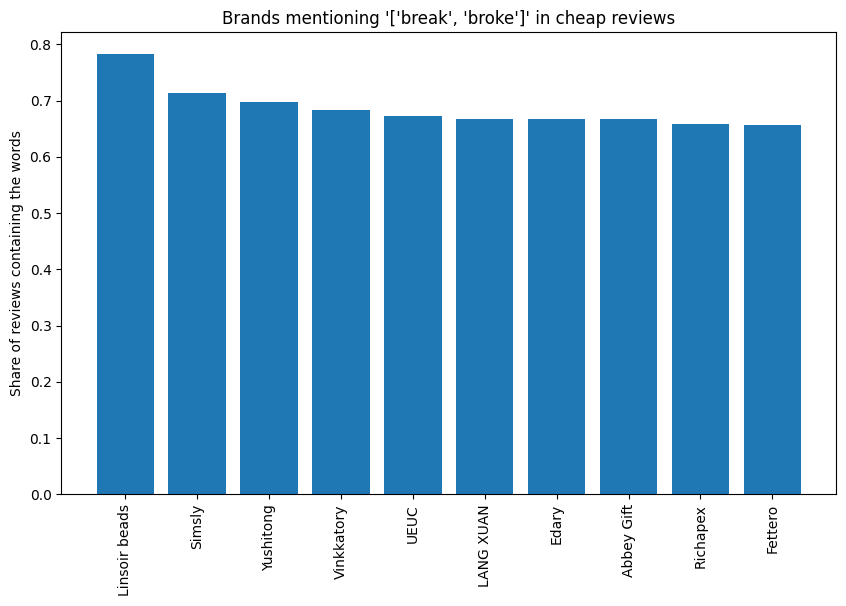

In [19]:
print("compare brands")
def compare_brands(df, word, segment, sentiment=None, min_reviews=20, top_n=10):
    temp = df[df['price_segment'] == segment].copy()
    if sentiment is not None:
        temp = temp[temp['sentiment'] == sentiment]
    # pattern = rf'\b{re.escape(word.lower())}\b'
    pattern = r'\b(' + '|'.join(re.escape(w.lower()) for w in word) + r')\b'
    temp['contains_word'] = temp['review'].str.contains(pattern, case=False, na=False)
    summary = temp.groupby('brand').agg(total_reviews=('contains_word', 'size'),reviews_with_word=('contains_word', 'sum'))
    summary['proportion'] = summary['reviews_with_word'] / summary['total_reviews']
    summary = summary[summary['total_reviews'] >= min_reviews]
    summary = summary.sort_values('proportion', ascending=False).head(top_n)
    print(summary)
    plt.figure(figsize=(10, 6))
    plt.bar(summary.index, summary['proportion'])
    plt.xticks(rotation=90)
    plt.ylabel("Share of reviews containing the words")
    plt.title(f"Brands mentioning '{word}' in {segment} reviews")
    plt.show()

compare_brands(products, ['break','broke'], 'cheap', sentiment='negative', min_reviews=20)